In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [6]:
q1age, q3age = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
q1fare, q3fare = df['Fare'].quantile(0.25), df['Fare'].quantile(0.75)

IQR_age, IQR_fare = q3age - q1age, q3fare - q1fare

lower_age, upper_age = q1age - 1.5 * IQR_age, q3age + 1.5 * IQR_age
lower_fare, upper_fare = q1fare - 1.5 * IQR_fare, q3fare + 1.5 * IQR_fare

df_no_outliers = df[(df['Age'].between(lower_age, upper_age)) & (df['Fare'].between(lower_fare, upper_fare))]

In [7]:
print(df_no_outliers[['Age', 'Fare']].describe())

              Age        Fare
count  721.000000  721.000000
mean    28.094313   17.389845
std     10.021961   13.563036
min      3.000000    0.000000
25%     22.000000    7.895800
50%     28.000000   12.275000
75%     33.000000   26.000000
max     54.000000   65.000000


In [8]:

print("Survived:\n", df['Survived'].value_counts())
print("\nPclass:\n", df['Pclass'].value_counts())
print("\nSex:\n", df['Sex'].value_counts())
print("\nEmbarked:\n", df['Embarked'].value_counts())


Survived:
 Survived
0    549
1    342
Name: count, dtype: int64

Pclass:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


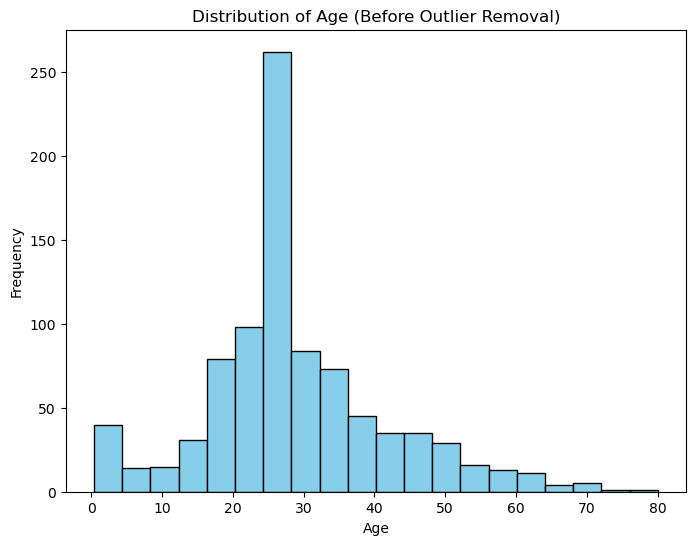

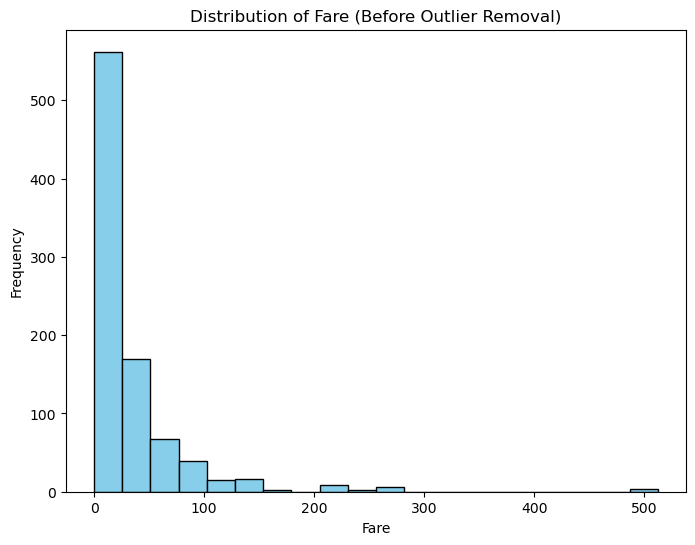

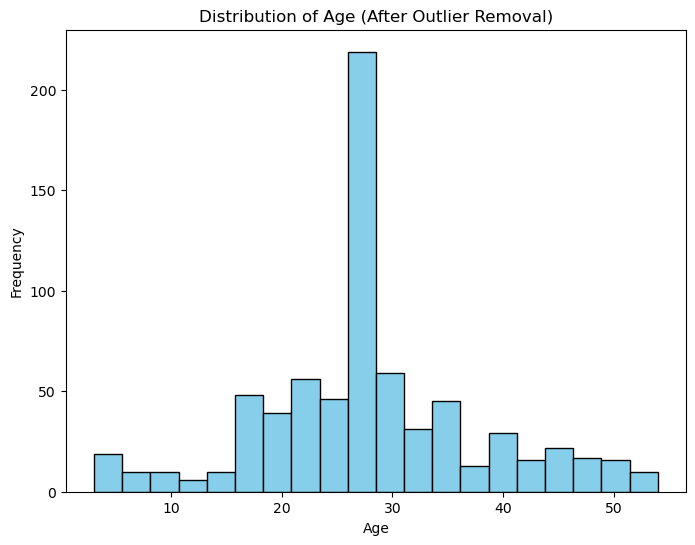

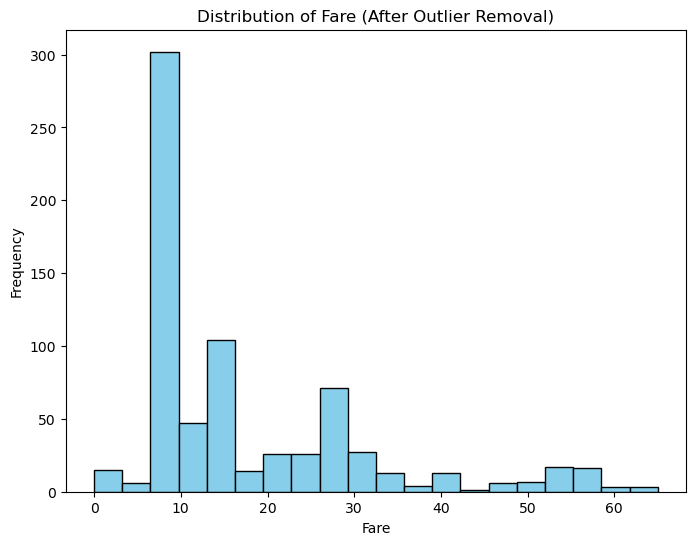

In [9]:
# Before removing outliers
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age (Before Outlier Removal)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df['Fare'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Fare (Before Outlier Removal)')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# After removing outliers
plt.figure(figsize=(8, 6))
plt.hist(df_no_outliers['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age (After Outlier Removal)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(df_no_outliers['Fare'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Fare (After Outlier Removal)')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()


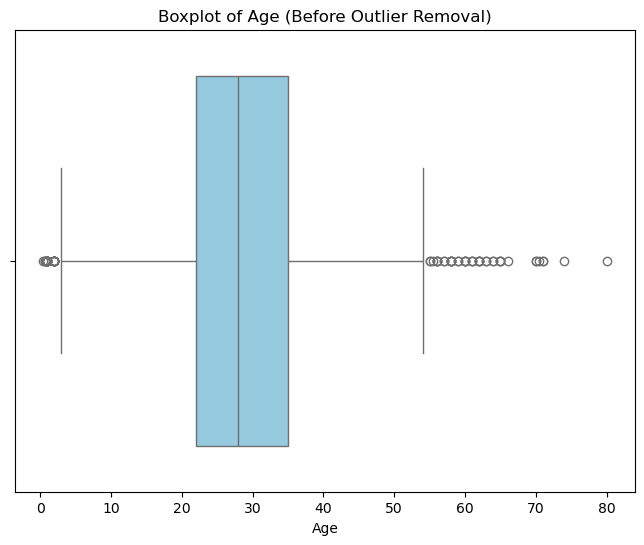

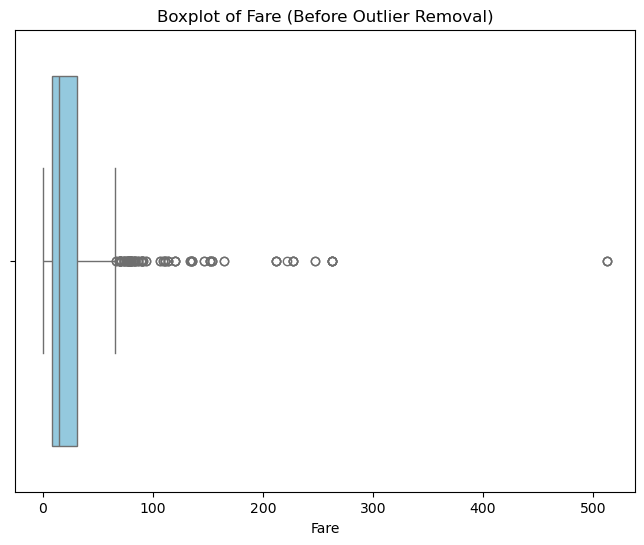

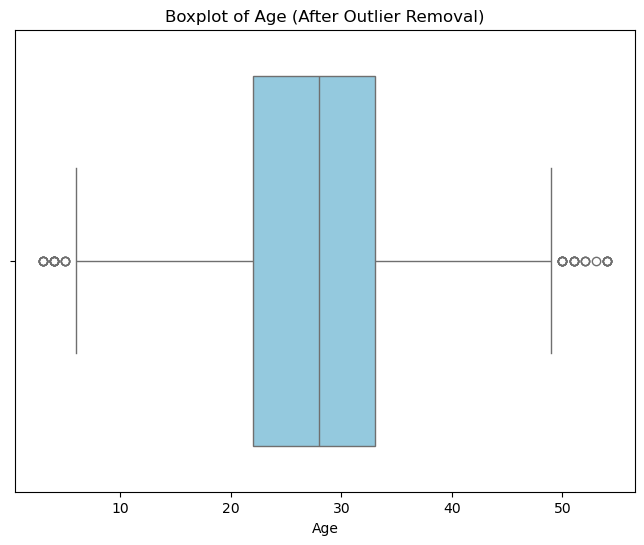

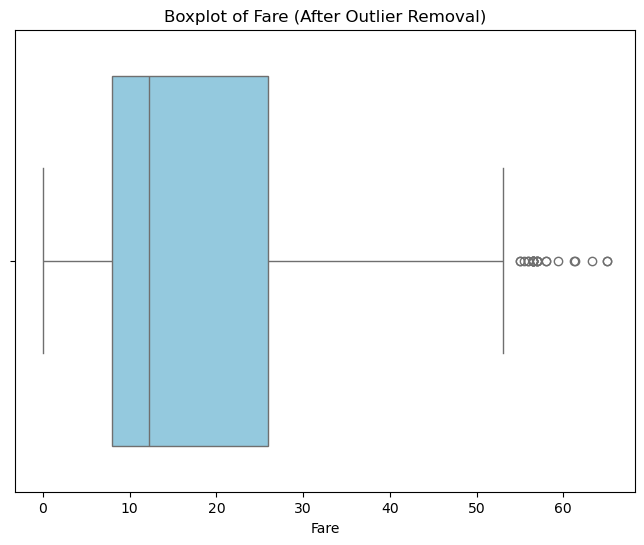

In [10]:
# Before removing outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot of Age (Before Outlier Removal)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Fare'], color='skyblue')
plt.title('Boxplot of Fare (Before Outlier Removal)')
plt.show()

# After removing outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_no_outliers['Age'], color='skyblue')
plt.title('Boxplot of Age (After Outlier Removal)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_no_outliers['Fare'], color='skyblue')
plt.title('Boxplot of Fare (After Outlier Removal)')
plt.show()


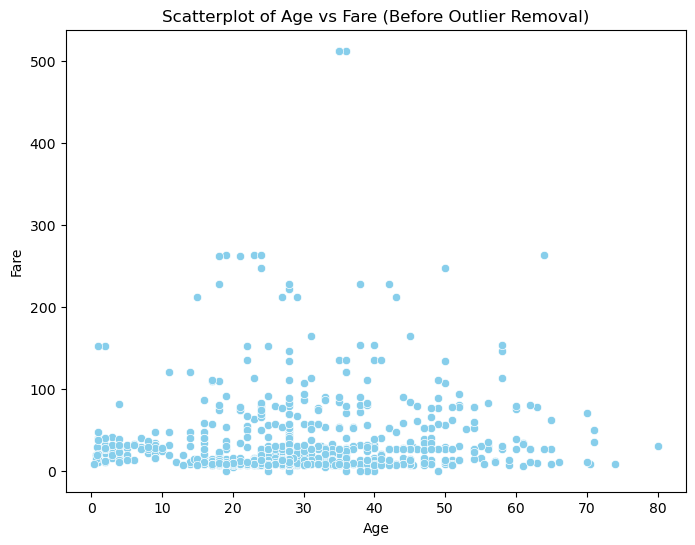

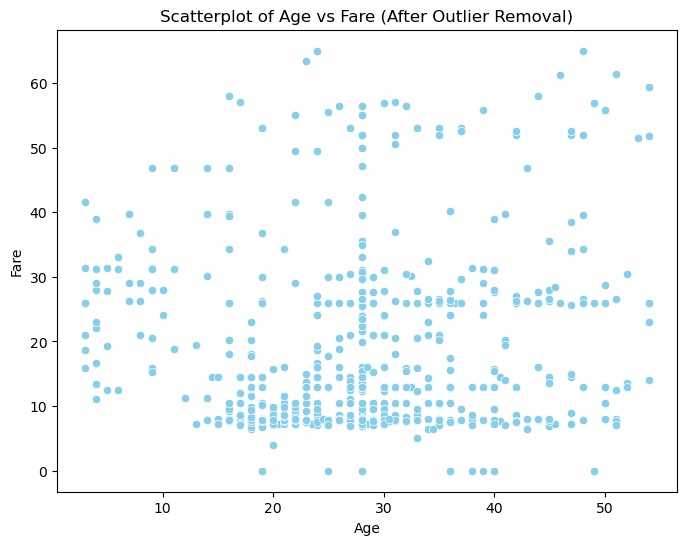

In [11]:
# Before removing outliers
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Fare', data=df, color='skyblue')
plt.title('Scatterplot of Age vs Fare (Before Outlier Removal)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

# After removing outliers
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Fare', data=df_no_outliers, color='skyblue')
plt.title('Scatterplot of Age vs Fare (After Outlier Removal)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


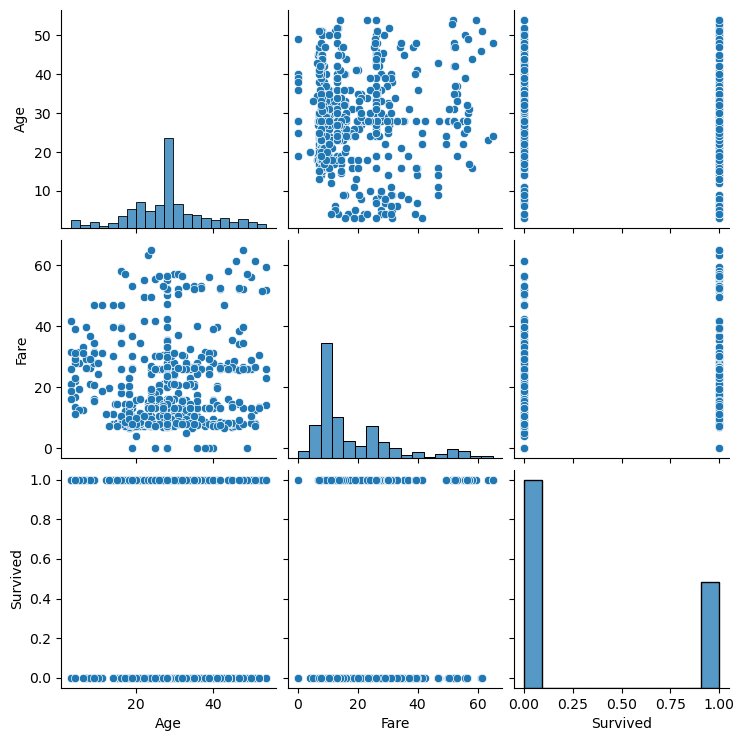

In [12]:
sns.pairplot(df_no_outliers[['Age', 'Fare', 'Survived']])
plt.show()

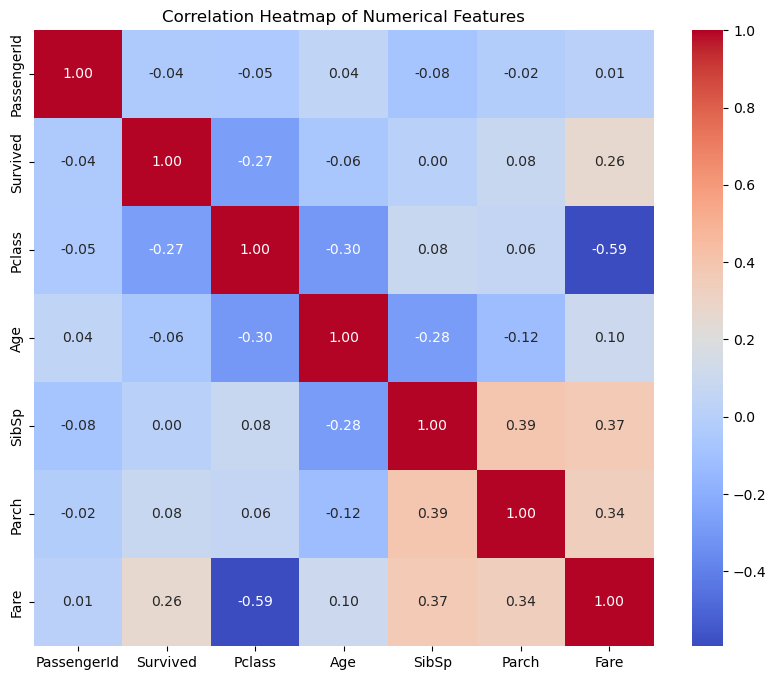

In [13]:
plt.figure(figsize=(10, 8))
numeric_df = df_no_outliers.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


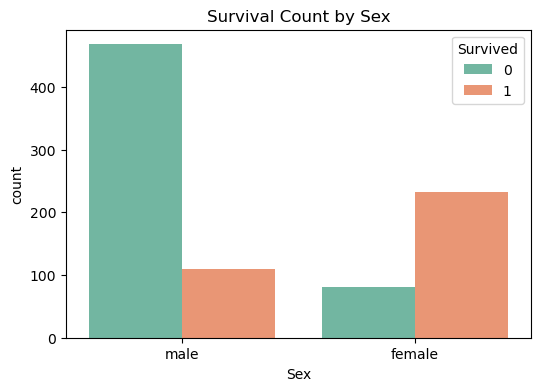

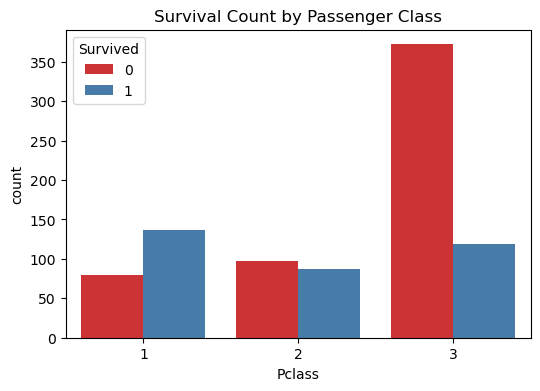

In [14]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Survival Count by Sex')
plt.show()

# 📌 Survived vs Pclass
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.show()
